now to increase accuracy 
first change sigmoid to relu 
then nodes 3-> 11
next add a layer
also increase epochs 
adding validation split 


In [51]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [52]:
df= pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [53]:
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [54]:
df.duplicated().sum()

np.int64(0)

In [55]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [56]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [57]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [58]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [59]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [60]:
df = pd.get_dummies(df, columns=['Geography','Gender'],drop_first=True)
# basically it converts the names in a column as 0 or 1 there are 3 in geography spain france germany 
# so it makes 3 columns and the first one is dropped


In [61]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [62]:
X=df.drop(columns=['Exited'])
y=df['Exited']
# X contains all columns except Exited
# y contains only the Exited column means the thing you want to predict 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=1)
# random_state ensures the same random split every time for reproducibility

In [63]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [64]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [65]:
X_train.shape

(8000, 11)

In [66]:
from sklearn.preprocessing import StandardScaler
# importing the standard scalar class
scaler = StandardScaler()
# creating an obj of the standard scalar class
scaler.fit(X_train)
# we get to know what the values are like 
# calculates and store the mean and standard deviation across all columns 
X_train_scaled = scaler.transform(X_train)
# now transformation using the formula stored in the variable
X_test_scaled = scaler.transform(X_test)

# we learn from training but transform both train and test data 

In [67]:
scaler.mean_

array([6.50313625e+02, 3.88872500e+01, 5.02500000e+00, 7.64634433e+04,
       1.53187500e+00, 7.07000000e-01, 5.11500000e-01, 1.00143430e+05,
       2.53750000e-01, 2.47000000e-01, 5.44250000e-01])

In [68]:
scaler.scale_
# standard deviation 

array([9.66709471e+01, 1.04682395e+01, 2.88567583e+00, 6.23686450e+04,
       5.83510055e-01, 4.55138440e-01, 4.99867733e-01, 5.75712856e+04,
       4.35156222e-01, 4.31266739e-01, 4.98038088e-01])

In [69]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [70]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense 

In [85]:
model = Sequential()

# here we will be doing 1 input 1 hidden- 3 perceptron 

# input layer + hidden layer 
model.add(Dense(11,activation='relu',input_dim=11))
model.add(Dense(11,activation='relu'))
# output latyer 
model.add(Dense(1,activation='sigmoid'))

In [86]:
model.summary()
# gives a summary of our model 

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['Accuracy'])
# adam generally works better

In [97]:
history=model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.8655 - loss: 0.3149 - val_Accuracy: 0.8544 - val_loss: 0.3472
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.8690 - loss: 0.3114 - val_Accuracy: 0.8519 - val_loss: 0.3473
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.8643 - loss: 0.3183 - val_Accuracy: 0.8550 - val_loss: 0.3479
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.8686 - loss: 0.3124 - val_Accuracy: 0.8556 - val_loss: 0.3469
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.8633 - loss: 0.3199 - val_Accuracy: 0.8500 - val_loss: 0.3482
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.8624 - loss: 0.3190 - val_Accuracy: 0.8519 - val_loss: 0.3495
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.8648 - loss: 0.3213 - val_Accuracy: 0.8500 - val_loss: 0.3494
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.8677 - loss: 0.3128 - val_Accu

In [90]:
# now the model has all thhe wrights and biases 
model.layers[0].get_weights()
# for thhe first layer these are the weights and the last line has the biases 

[array([[ 0.5299681 ,  0.32700375,  0.19348095, -0.01085706, -0.24314445,
          0.19671628,  0.23932542, -0.23869157, -0.00594307,  0.09587052,
         -0.02780345],
        [-0.4517759 , -0.3608883 ,  0.44885376, -0.3213827 ,  0.5247427 ,
         -1.3095495 ,  1.2226346 , -1.1069448 ,  0.386709  , -0.25933647,
         -0.39317033],
        [-0.29647204,  0.2071632 , -0.16829193, -0.00857912,  0.26205418,
         -0.3300576 ,  0.06423028,  0.45441234, -0.16685382,  0.06740553,
         -0.06729354],
        [-0.07039099, -0.17131992,  0.5623288 ,  0.00671204,  0.43726438,
          0.34416664, -0.41373542, -0.2078814 ,  0.519261  ,  0.65382326,
          0.5087831 ],
        [ 0.49378353, -0.26471   , -0.01575912, -1.3379873 , -0.25542775,
         -0.49786958, -0.13657077,  0.09681033,  0.7304499 ,  1.0307367 ,
          0.29678437],
        [-0.3903807 ,  0.39523563,  0.20156133, -0.17048909, -0.12250056,
          0.25546724, -0.17118004,  0.06219193, -0.09458739, -0.1092541

In [91]:
# now the model has all thhe wrights and biases 
model.layers[1].get_weights()
# 

[array([[-0.21834819, -0.12149895,  0.01848621,  0.49308056,  0.43520018,
          0.41969523, -0.88793176, -0.04888762, -0.0136553 ,  0.44081694,
         -0.46065637],
        [ 0.24448027,  0.610265  ,  0.14734001,  0.5359402 ,  0.37255052,
          0.46902964, -0.16414884, -0.16230005, -0.26808852, -0.16771531,
         -0.81603247],
        [-0.14742778,  0.05936217,  0.04252626,  0.06283866,  0.04910161,
          0.04764223,  0.60587674,  0.33376235,  0.6419016 , -0.09096646,
          0.35881862],
        [-0.16345474,  0.6582527 , -0.87874264, -0.22361763, -0.46773174,
          0.05231839,  0.12009575,  0.5441567 , -0.84706545, -0.02424794,
         -0.20643277],
        [-0.33079585, -0.84728706,  0.8478611 ,  0.35434642, -0.13106905,
          0.07244292,  0.38115078,  0.1161082 ,  0.23250614,  0.08882803,
          0.4191207 ],
        [-0.79746   , -0.45339173,  0.14064723, -0.34818098, -0.00683215,
         -0.02406045, -0.07619686, -0.8809435 ,  0.09629466, -0.7260118

In [92]:
# now prediction portion 
model.predict(X_test_scaled)
# noww since we are using sigmoid its givinga probability 
# to tranform into binary 
# we just give a threshold here 
# 0.5 is the threshold <0.5 customer leaves >0.5 customer stays

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.02470022],
       [0.15050367],
       [0.04262121],
       ...,
       [0.00918567],
       [0.0415917 ],
       [0.2868391 ]], dtype=float32)

In [93]:
y_log=model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [94]:
y_pred=np.where(y_log>0.5,1,0)
# where y_log is >0.5 output 1 else outputt 0 

In [95]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)
# actual data and predicted data 

0.8635

In [81]:
# now i will be experimenmting to increase accuracy 

In [96]:
import matplotlib.pyplot as plt

In [98]:
history.history
# gives me a dictionary

{'Accuracy': [0.8670312762260437,
  0.8667187690734863,
  0.8678125143051147,
  0.8675000071525574,
  0.867968738079071,
  0.8673437237739563,
  0.8682812452316284,
  0.8670312762260437,
  0.8681250214576721,
  0.8698437213897705,
  0.8675000071525574,
  0.8690624833106995,
  0.8684375286102295,
  0.867968738079071,
  0.8689062595367432,
  0.8696874976158142,
  0.8681250214576721,
  0.8698437213897705,
  0.8696874976158142,
  0.8696874976158142,
  0.8704687356948853,
  0.8673437237739563,
  0.8690624833106995,
  0.8678125143051147,
  0.8721874952316284,
  0.8684375286102295,
  0.8700000047683716,
  0.8701562285423279,
  0.8696874976158142,
  0.8696874976158142,
  0.8706250190734863,
  0.8695312738418579,
  0.870312511920929,
  0.8693749904632568,
  0.8690624833106995,
  0.8700000047683716,
  0.87109375,
  0.8704687356948853,
  0.8695312738418579,
  0.8704687356948853,
  0.8704687356948853,
  0.8714062571525574,
  0.8729687333106995,
  0.8721874952316284,
  0.8696874976158142,
  0.87124

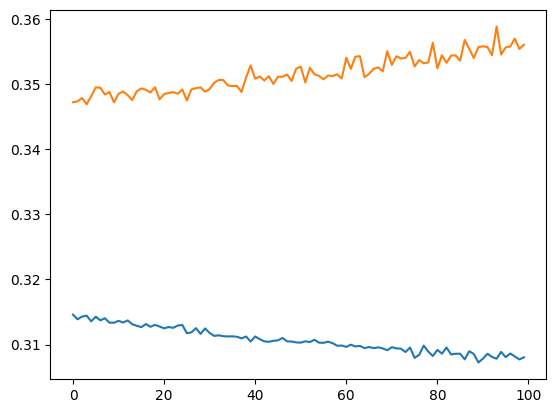

In [100]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

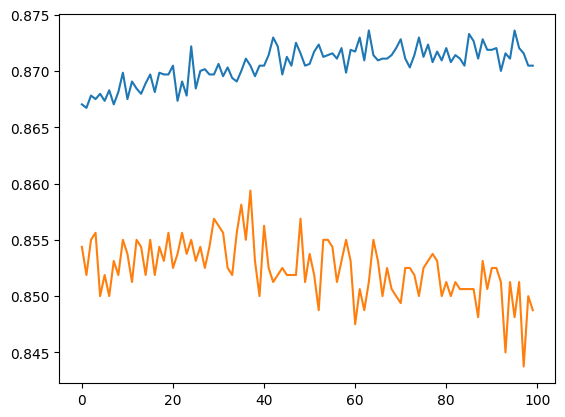

In [105]:
plt.plot(history.history['Accuracy'])
plt.plot(history.history['val_Accuracy'])